In [28]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from timm.loss import SoftTargetCrossEntropy # Because we are using Cutmix function
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from tqdm import tqdm
from torchvision.transforms import autoaugment
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
import io

What is done?
- Augmentation functions such as CutMix and mixup are created
- Train and test are created using train_test_split.txt file offered with the
  dataset (typical standard approach with the CUB dataset)
- val and train data are seperated using straftified sampling
- further transforms functions such as color jittering, randaugment, flippings, randomerasing are used

The goal is to first:
- see the performance of resNet finetuned on train data on test set
  * See the Peformance with different hyperparameters changes (maybe changes in growth rate, batch size, learning rate)  are done
- see the performance of resNet combined with PSA (Polarized Self Attention) on test set
   * See the Peformance with different hyperparameters changes (maybe changes in growth rate, batch size, learning rate)  are done

   

> For the hyperparameters values though because each training takes a lot of time, only some instances are observed. -> This ia typical limitation with the current experiment (Further optimizations and hyperparametrs tuning might offer even better performance than currently observed)

## Data Preprocessing

Cutmix implementation idea Link: https://github.com/ildoonet/cutmix/blob/master/cutmix/utils.py

In [ ]:
#Paths

Data_dir = r'/home/kkharel2/DL_Proj/CUB-200/data'


##### Define Transformations for train and test dataset
- additionally cutmix function is defined (useful for training in fine grained classification task)

In [ ]:
# Simple Augmentations idea for train dataset (We don't augment test dataset and even validation set)
# For test dataset simple resize, CenterCrop and Normalize is done

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    autoaugment.RandAugment(),  # Apply RandAugment
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33)),  # Random erasing
])                                                        # CutMix and mixup is done later during training process itself

base_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])


In [1]:
''' The main idea in cutmix is to combine two images by cutting patch from one and pasting to another
    On doing so, labels are also mixed proportionally to the area of patches. '''


def cutmix_data(inputs, targets, alpha=1.0):


    '''
    Parameters:
        inputs (torch.Tensor): A batch of input images shape: [batch_size, channels, height, width].
        targets (torch.Tensor): batch of target lables corresponding to input images
        alpha (float): The alpha parameter for the Beta distribution. sample mixing ratio lam depends on its value

    Return:
        inputs (torch.Tensor): The batch of images after applying CutMix.
        targets (torch.Tensor): The mixed labels corresponding to the CutMix images.
    '''

    assert alpha > 0,                "Alpha should be greater than zero"

    lam = np.random.beta(alpha, alpha)
    batch_size = inputs.size(0)
    index = torch.randperm(batch_size).to(inputs.device)

    # Get shuffled inputs and targets
    shuffled_inputs = inputs[index]
    shuffled_targets = targets[index]

    # Get bounding box for CutMix
    bbx1, bby1, bbx2, bby2 = rand_bbox(inputs.size(), lam)
    inputs[:, :, bbx1:bbx2, bby1:bby2] = shuffled_inputs[:, :, bbx1:bbx2, bby1:bby2]

    # Adjust lambda based on the area of the box
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (inputs.size(-1) * inputs.size(-2)))

    # Combine labels
    targets = lam * targets + (1 - lam) * shuffled_targets

    return inputs, targets


def rand_bbox(size, lam):
    ''' Generate random bounding box '''

    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # uniform
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)  # Left Boundary
    bby1 = np.clip(cy - cut_h // 2, 0, H)  # Top Boundary
    bbx2 = np.clip(cx + cut_w // 2, 0, W)  # Right Boundary
    bby2 = np.clip(cy + cut_h // 2, 0, H)  # Bottom Boundary

    return bbx1, bby1, bbx2, bby2


## Applying Mixup augmentation strategy

def mixup_data(inputs, targets, alpha=1.0):
    '''
    Applies MixUp augmentation to a batch of inputs and targets.
    Args:
        inputs (torch.Tensor): Input images of shape [batch_size, channels, height, width].
        targets (torch.Tensor): One-hot encoded labels of shape [batch_size, num_classes].
        alpha (float): MixUp alpha parameter (controls the mixing ratio).
    Returns:
        mixed_inputs (torch.Tensor): Mixed images.
        mixed_targets (torch.Tensor): Mixed one-hot encoded labels.
    '''

    lam = np.random.beta(alpha, alpha)
    batch_size = inputs.size(0)
    index = torch.randperm(batch_size).to(inputs.device)

    mixed_inputs = lam * inputs + (1 - lam) * inputs[index]
    mixed_targets = lam * targets + (1 - lam) * targets[index]
    return mixed_inputs, mixed_targets


In [ ]:
# Loading train and test dataset (creating a validation set from subset of train set)

def prepare_dataset():

    # Load the full training dataset without transformations
    full_train_dataset = datasets.ImageFolder(
        r'/home/kkharel2/DL_Proj/CUB-200/data/train'
    )

    # Stratified split to create train and validation indices
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=8)
    train_indices, val_indices = next(sss.split(np.zeros(len(full_train_dataset)), full_train_dataset.targets))

    # Creating training dataset with augmentation
    train_dataset = Subset(
        datasets.ImageFolder(
            r'/home/kkharel2/DL_Proj/CUB-200/data/train',
            transform=train_transform
        ),
        train_indices
    )

    # Create validation dataset without augmentation
    val_dataset = Subset(
        datasets.ImageFolder(
            r'/home/kkharel2/DL_Proj/CUB-200/data/train',
            transform=base_transform
        ),
        val_indices
    )

    # Load the test dataset with base transformations
    test_dataset = datasets.ImageFolder(
        r'/home/kkharel2/DL_Proj/CUB-200/data/test',
        transform=base_transform
    )

    return train_dataset, val_dataset, test_dataset

### Implementing ResNet (only) for classification task
- What I want to see is the change in performance which can be obtained if we use ResNet combined with PSA as compared to ResNet alone.

In [ ]:
# Loading pretrained resNet50

class BaselineResNet(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
## Defining the parameters

batchsize=32
weight_decay = 10^-4
lr = 10^-3
t_max = 10
alpha = 0.4
alpha2 = 1
name = 'name'
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'

In [ ]:
### Hyperparametrs we are looking to observe are weight_decay, learning_rate, T_max, alpha (for cutmix), alpha2 (for mixup)

def train_model(batch_size = batchsize, weight_decay = weight_decay, learning_rate = lr, T_max = t_max, alpha = alpha, alpha2 = alpha2, name_exp = name):
    train_dataset, val_dataset, test_dataset = prepare_dataset()
    batch_size = batch_size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
    model = BaselineResNet(num_classes=200).to(device)

    criterion_train = SoftTargetCrossEntropy()  # Because train dataset has CutMix/MixUp applied
    criterion_val = nn.CrossEntropyLoss()      # Val dataset doesn't use CutMix/MixUp
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay= weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)

    best_val_acc = 0.0
    patience = 7        # Number of epochs to wait after last time validation accuracy improved
    epochs_without_improvement = 0

    # Dictionary to store training and validation losses
    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in tqdm(range(100), desc="Epochs", position=0):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, targets in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False, position=1):
            inputs, targets = inputs.to(device), targets.to(device)
            targets = F.one_hot(targets, num_classes=200).float()

            # Randomly choose between CutMix and MixUp
            if np.random.rand() < 0.5:  # 50% chance of using CutMix
                mixed_inputs, mixed_targets = cutmix_data(inputs, targets, alpha= alpha)
            else:  # 50% chance of using MixUp
                mixed_inputs, mixed_targets = mixup_data(inputs, targets, alpha= alpha2)

            optimizer.zero_grad()
            outputs = model(mixed_inputs)
            loss = criterion_train(outputs, mixed_targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(mixed_targets.argmax(1)).sum().item()

        # Calculate average training loss for the epoch
        avg_train_loss = train_loss / len(train_loader)

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        model.eval()
        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}", leave=False, position=1):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion_val(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()

        # Calculate average validation loss and accuracy for the epoch
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total

        # Log the epoch, training loss, validation loss, and validation accuracy
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        tqdm.write(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.2f}%')

        if val_acc > best_val_acc:
            torch.save(model.state_dict(), f'{name_exp}.pth')
            best_val_acc = val_acc
            epochs_without_improvement = 0  # Reset the counter
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            tqdm.write(f'Early stopping at epoch {epoch+1} as validation accuracy did not improve for {patience} epochs.')
            break

        scheduler.step()

    tqdm.write(f'Best Validation Accuracy: {best_val_acc:.2f}%')

    # Return the history dictionary for plotting
    return history

##### Experiment 1:
lr = 3e-4, weight_decay = 5e-4, T_max = 75, alpha(cutmix) = 1, alpha2(MixUp) = 0.4

In [ ]:
base_history1 = train_model(32, 3e-4, 5e-4, 75, 1, 0.4, 'base_resnet1')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:52<?, ?it/s]

Epoch 1: Train Loss = 5.4038, Val Loss = 5.5827, Val Acc = 0.58%


Epochs:   1%|          | 1/100 [01:45<1:27:52, 53.25s/it]

Epoch 2: Train Loss = 5.3241, Val Loss = 5.3027, Val Acc = 0.92%


Epochs:   2%|▏         | 2/100 [02:38<1:26:38, 53.05s/it]

...

Epoch 82: Train Loss = 3.8154, Val Loss = 2.4162, Val Acc = 38.78%


Epochs:  83%|████████▎ | 83/100 [1:15:05<15:23, 54.34s/it]

Epoch 83: Train Loss = 3.8398, Val Loss = 2.3982, Val Acc = 38.95%


Epochs:  83%|████████▎ | 83/100 [1:15:57<15:33, 54.91s/it]

Epoch 84: Train Loss = 3.8162, Val Loss = 2.3840, Val Acc = 39.62%
Early stopping at epoch 84 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 39.78%


##### Experiment 2:
lr = 5e-5, weight_decay = 1e-5, T_max = 10, alpha(cutmix) = 0.5, alpha2(MixUp) = 0.5

In [ ]:
base_history2 = train_model(32, 1e-5, 5e-5, 10, 0.5, 0.5, 'base_resnet2')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [05:12<?, ?it/s]

Epoch 1: Train Loss = 5.2512, Val Loss = 4.4740, Val Acc = 11.18%


Epochs:   1%|          | 1/100 [10:25<8:37:14, 313.48s/it]

Epoch 2: Train Loss = 4.8183, Val Loss = 3.6599, Val Acc = 25.69%


Epochs:   2%|▏         | 2/100 [14:44<8:32:07, 313.55s/it]

...

Epoch 38: Train Loss = 2.8542, Val Loss = 1.0523, Val Acc = 74.48%


Epochs:  39%|███▉      | 39/100 [3:12:15<3:13:05, 189.92s/it]

Epoch 39: Train Loss = 2.8012, Val Loss = 1.0309, Val Acc = 74.56%


Epochs:  39%|███▉      | 39/100 [3:16:13<5:06:54, 301.89s/it]

Epoch 40: Train Loss = 2.6975, Val Loss = 1.0732, Val Acc = 73.81%
Early stopping at epoch 40 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 75.98%


Experiment 3:

lr = 1e-4, weight_decay = 1e-5, T_max = 30, alpha(cutmix) = 0.3, alpha2(MixUp) = 0.1

In [ ]:
base_history3 = train_model(32, 1e-5, 1e-4, 20, 0.3, 0.1, 'base_resnet3')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [04:08<?, ?it/s]

Epoch 1: Train Loss = 5.0544, Val Loss = 3.7281, Val Acc = 17.18%


Epochs:   1%|          | 1/100 [07:03<6:50:58, 249.08s/it]

Epoch 2: Train Loss = 4.2740, Val Loss = 2.9224, Val Acc = 31.78%


Epochs:   2%|▏         | 2/100 [13:05<5:36:40, 206.12s/it]

...

Epoch 27: Train Loss = 2.2586, Val Loss = 0.9520, Val Acc = 75.56%


Epochs:  28%|██▊       | 28/100 [2:06:48<5:44:40, 287.23s/it]

Epoch 28: Train Loss = 2.3536, Val Loss = 0.9569, Val Acc = 75.98%


Epochs:  28%|██▊       | 28/100 [2:12:49<5:41:33, 284.63s/it]

Epoch 29: Train Loss = 2.2797, Val Loss = 0.9255, Val Acc = 75.48%
Early stopping at epoch 29 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 76.98%


Experiment 4:

lr = 1e-4, weight_decay = 1e-5, T_max = 30, alpha(cutmix) = 0.3, alpha2(MixUp) = 0.1



In [ ]:
base_history4 = train_model(32, 1e-5, 1e-5, 30, 0.3, 0.1, 'base_resnet4')


/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:50<?, ?it/s]

Epoch 1: Train Loss = 5.3240, Val Loss = 5.2036, Val Acc = 2.00%


Epochs:   1%|          | 1/100 [01:41<1:24:02, 50.93s/it]

Epoch 2: Train Loss = 5.2329, Val Loss = 5.0240, Val Acc = 8.26%


Epochs:   2%|▏         | 2/100 [02:34<1:23:13, 50.96s/it]

...

Epoch 35: Train Loss = 3.7161, Val Loss = 2.4162, Val Acc = 52.13%


Epochs:  36%|███▌      | 36/100 [30:39<54:09, 50.78s/it]

Epoch 36: Train Loss = 3.8057, Val Loss = 2.3935, Val Acc = 52.04%


Epochs:  36%|███▌      | 36/100 [31:30<56:00, 52.51s/it]

Epoch 37: Train Loss = 3.7416, Val Loss = 2.4100, Val Acc = 51.54%
Early stopping at epoch 37 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 52.46%


Experiment 5:

lr = 1e-4, weight_decay = 1e-5, T_max = 30, alpha(cutmix) = 0.3, alpha2(MixUp) = 0.5

In [ ]:
base_history5 = train_model(32, 1e-5, 1e-4, 30, 0.3, 0.3, 'base_resnet5')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [05:54<?, ?it/s]

Epoch 1: Train Loss = 5.0852, Val Loss = 3.8303, Val Acc = 17.51%


Epochs:   1%|          | 1/100 [10:11<9:48:03, 356.40s/it]

Epoch 2: Train Loss = 4.4444, Val Loss = 3.0437, Val Acc = 28.77%


Epochs:   2%|▏         | 2/100 [12:24<8:05:10, 297.04s/it]

...

Epoch 38: Train Loss = 2.3952, Val Loss = 0.9163, Val Acc = 77.90%


Epochs:  39%|███▉      | 39/100 [2:40:14<4:40:40, 276.08s/it]

Epoch 39: Train Loss = 2.1526, Val Loss = 0.8795, Val Acc = 78.15%


Epochs:  39%|███▉      | 39/100 [2:47:10<4:21:29, 257.20s/it]

Epoch 40: Train Loss = 2.2553, Val Loss = 0.9072, Val Acc = 77.81%
Early stopping at epoch 40 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 78.15%


Experiment 6:

lr = 1e-4, weight_decay = 5e-5, T_max = 30, alpha(cutmix) = 0.2, alpha2(MixUp) = 0.2

In [ ]:
base_history6 = train_model(32, 5e-5, 1e-4, 20, 0.2, 0.2, 'base_resnet6')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [01:02<?, ?it/s]

Epoch 1: Train Loss = 5.0663, Val Loss = 3.9099, Val Acc = 16.68%


Epochs:   1%|          | 1/100 [02:05<1:44:08, 63.12s/it]

Epoch 2: Train Loss = 4.3741, Val Loss = 2.9977, Val Acc = 27.77%


Epochs:   2%|▏         | 2/100 [03:08<1:43:00, 63.06s/it]

...

Epoch 24: Train Loss = 2.1994, Val Loss = 0.9555, Val Acc = 76.65%


Epochs:  25%|██▌       | 25/100 [26:17<1:17:59, 62.40s/it]

Epoch 25: Train Loss = 2.2896, Val Loss = 0.9828, Val Acc = 76.56%


Epochs:  25%|██▌       | 25/100 [27:19<1:21:59, 65.60s/it]

Epoch 26: Train Loss = 2.3530, Val Loss = 0.9493, Val Acc = 76.56%
Early stopping at epoch 26 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 77.23%


#### Choosing the best performing on val_set as the one for testing
- For that case we retrain with lower batch_size for that model (it is found that for fine grained classification lower batch_size might perform better than the other one)

In [ ]:
base_history_lbatchsize = train_model(16,1e-5, 1e-4, 30, 0.3, 0.3, 'base_resnet5_lbatchsize')  ## Put the parameters for that of best model here


/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:51<?, ?it/s]

Epoch 1: Train Loss = 5.0953, Val Loss = 3.8356, Val Acc = 13.68%


Epochs:   1%|          | 1/100 [01:43<1:24:53, 51.45s/it]

Epoch 2: Train Loss = 4.5366, Val Loss = 2.9864, Val Acc = 25.02%


Epochs:   2%|▏         | 2/100 [02:35<1:24:28, 51.72s/it]

...

Epoch 34: Train Loss = 2.4992, Val Loss = 0.8761, Val Acc = 77.40%


Epochs:  35%|███▌      | 35/100 [29:57<55:23, 51.13s/it]

Epoch 35: Train Loss = 2.5967, Val Loss = 0.9064, Val Acc = 76.90%


Epochs:  35%|███▌      | 35/100 [30:48<57:12, 52.81s/it]

Epoch 36: Train Loss = 2.5845, Val Loss = 0.9108, Val Acc = 77.73%
Early stopping at epoch 36 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 77.73%


In [ ]:
history_base = base_history5

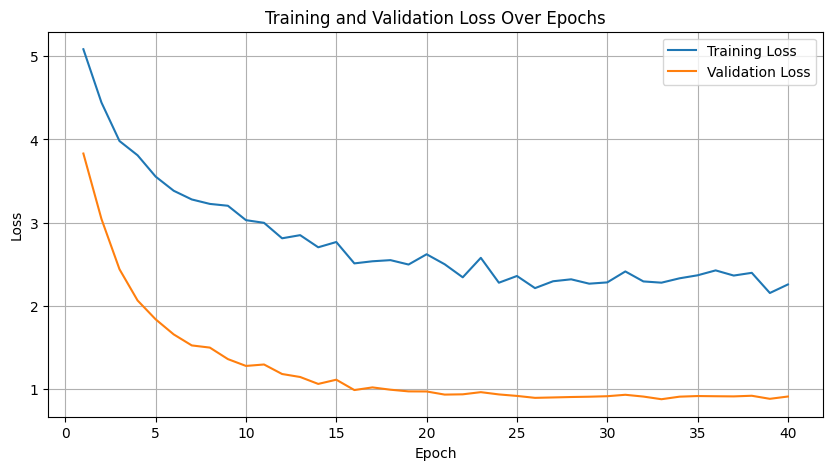

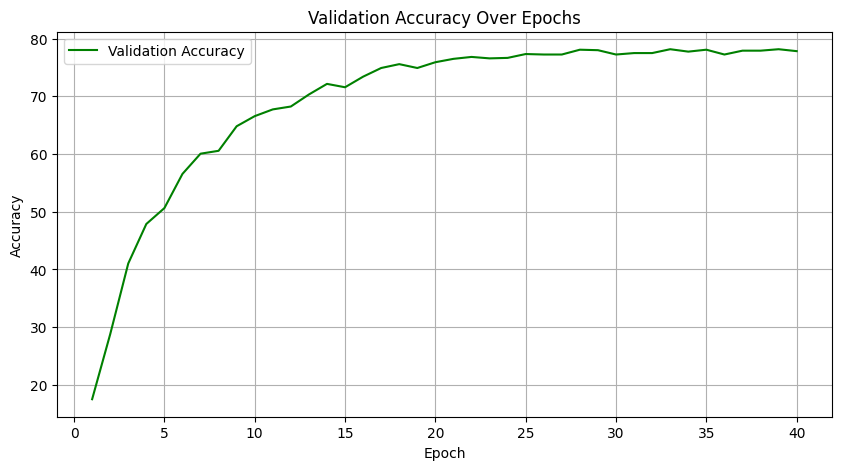

In [ ]:
# # Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(history_base['epoch'], history_base['train_loss'], label='Training Loss')
plt.plot(history_base['epoch'], history_base['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

# Plot validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_base['epoch'], history_base['val_acc'], label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = BaselineResNet().to(device)  # Moving model to the appropriate device
    model.load_state_dict(torch.load('base_resnet4.pth'))
    model.eval()

    test_dataset = datasets.ImageFolder('data/test', transform=base_transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            all_preds.append(outputs.argmax(1).cpu())
            all_targets.append(targets.cpu())  # Moving targets back to CPU for evaluation

    all_preds = torch.cat(all_preds).numpy()  # Conversion to numpy array
    all_targets = torch.cat(all_targets).numpy()

    # Calculate overall accuracy
    acc = (all_preds == all_targets).mean()
    print(f'Final Test Accuracy: {acc*100:.4f}%')

    # Generate classification report
    class_names = test_dataset.classes
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))

In [ ]:
evaluate_model()

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Final Test Accuracy: 75.0604%

Classification Report:
                                    precision    recall  f1-score   support

        001.Black_footed_Albatross       0.50      0.73      0.59        30
              002.Laysan_Albatross       0.81      0.83      0.82        30
               003.Sooty_Albatross       0.73      0.86      0.79        28
             004.Groove_billed_Ani       0.80      0.93      0.86        30
                005.Crested_Auklet       0.77      0.71      0.74        14
                  006.Least_Auklet       0.91      0.91      0.91        11
               007.Parakeet_Auklet       0.92      0.96      0.94        23
             008.Rhinoceros_Auklet       0.84      0.89      0.86        18
              009.Brewer_Blackbird       0.40      0.28      0.33        29
          010.Red_winged_Blackbird       0.82      0.93      0.88        30
               011.Rusty_Blackbird       0.57      0.57      0.57        30
       012.Yellow_headed_Blackbir

### Implementing ResNet attached with PSA block
- What I want to see is the change in performance which can be obtained if we use ResNet combined with PSA as compared to ResNet alone.

Link to the paper: https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://arxiv.org/abs/2107.00782&ved=2ahUKEwiOr53Q8P-LAxUcgP0HHcKyBQkQFnoECBYQAQ&usg=AOvVaw27-P4DDI5XmFgExfuhqdvf

LINK TO THE PSA IMPLEMENTATION CODE: https://github.com/DeLightCMU/PSA/blob/main/semantic-segmentation/network/PSA.py

In [6]:
from torchvision.models import resnet50

## PSA in this project is a bit simplified version as comparerd to the implemetnation in the original paper

class PolarizedSelfAttention(nn.Module):
    def __init__(self, channel):
        super().__init__()
        self.channel_conv = nn.Conv2d(channel, channel//2, 1)
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channel//2, channel, 1),
            nn.Sigmoid())

        self.spatial_conv = nn.Conv2d(channel, channel//2, 3, padding=1)
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(channel//2, 1, 1),
            nn.Sigmoid())

        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        # Channel attention
        channel_feat = self.channel_conv(x)
        channel_att = self.channel_attention(channel_feat)

        # Spatial attention
        spatial_feat = self.spatial_conv(x)
        spatial_att = self.spatial_attention(spatial_feat)

        return x + self.gamma * (x * channel_att + x * spatial_att)


In [7]:
class ResNetPSA(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()

        # Load pretrained ResNet-50
        self.model = resnet50(pretrained=True)

        # Freeze early layers
        for param in self.model.conv1.parameters():
            param.requires_grad = False
        for param in self.model.layer1.parameters():
            param.requires_grad = False
        for param in self.model.layer2.parameters():
            param.requires_grad = False

        # Add PSA blocks after layer3 and layer4 (not inside)
        self.psa3 = PolarizedSelfAttention(1024)  # After layer3
        self.psa4 = PolarizedSelfAttention(2048)  # After layer4

        # Replace final layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        # Standard ResNet forward with PSA additions
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
        x = self.psa3(x)  # Add PSA after layer3
        x = self.model.layer4(x)
        x = self.psa4(x)  # Add PSA after layer4

        x = self.model.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.model.fc(x)
        return x

In [ ]:
def train_model(batch_size = batchsize, learning_rate = lr, weight_decay= weight_decay, T_max = t_max, alpha1 = alpha, alpha2 = alpha2, name= name):
    train_dataset, val_dataset, test_dataset = prepare_dataset()
    batch_size = batch_size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
    model = ResNetPSA(num_classes=200).to(device)

    criterion_train = SoftTargetCrossEntropy()
    criterion_val = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_max)

    best_val_acc = 0.0
    patience = 7  # Number of epochs to wait after last time validation accuracy improved
    epochs_without_improvement = 0

    # Dictionary to store training and validation losses
    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in tqdm(range(100), desc="Epochs", position=0):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, targets in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False, position=1):
            inputs, targets = inputs.to(device), targets.to(device)
            targets = F.one_hot(targets, num_classes=200).float()

            # Randomly choose between CutMix and MixUp
            if np.random.rand() < 0.5:  # 50% chance of using CutMix
                mixed_inputs, mixed_targets = cutmix_data(inputs, targets, alpha=alpha1)
            else:  # 50% chance of using MixUp
                mixed_inputs, mixed_targets = mixup_data(inputs, targets, alpha=alpha2)

            optimizer.zero_grad()
            outputs = model(mixed_inputs)
            loss = criterion_train(outputs, mixed_targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(mixed_targets.argmax(1)).sum().item()

        # Calculate average training loss for the epoch
        avg_train_loss = train_loss / len(train_loader)

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        model.eval()
        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc=f"Validation Epoch {epoch+1}", leave=False, position=1):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion_val(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()

        # Calculate average validation loss and accuracy for the epoch
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total

        # Log the epoch, training loss, validation loss, and validation accuracy
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        tqdm.write(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.2f}%')

        if val_acc > best_val_acc:
            torch.save(model.state_dict(), f'{name}.pth')
            best_val_acc = val_acc
            epochs_without_improvement = 0  # Reset the counter
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            tqdm.write(f'Early stopping at epoch {epoch+1} as validation accuracy did not improve for {patience} epochs.')
            break

        scheduler.step()

    tqdm.write(f'Best Validation Accuracy: {best_val_acc:.2f}%')

    # Return the history dictionary for plotting
    return history

#### Experiment 1:
lr = 3e^-4, Weight_decay = 5e^-4, T_max = 75, alpha1 = 0.8, alpha2 = 0.3

In [ ]:
#train_model(batch_size = 32, learning_rate = lr, weight_decay= weight_decay, T_max = T, alpha1 = alpha1, alpha2 = alpha2, name= name):

mod_history1 = train_model(32, 3e-4, 5e-4, 75, 0.8, 0.3, 'resnetpsaexp1')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:53<?, ?it/s]

Epoch 1: Train Loss = 5.3677, Val Loss = 5.1202, Val Acc = 1.92%


Epochs:   1%|          | 1/100 [01:45<1:29:29, 54.24s/it]

Epoch 2: Train Loss = 5.0104, Val Loss = 4.2470, Val Acc = 9.42%


Epochs:   2%|▏         | 2/100 [02:37<1:26:22, 52.88s/it]

...

Epoch 71: Train Loss = 2.1408, Val Loss = 0.9745, Val Acc = 77.23%


Epochs:  72%|███████▏  | 72/100 [1:03:02<25:51, 55.41s/it]

Epoch 72: Train Loss = 2.0817, Val Loss = 0.9589, Val Acc = 77.06%


Epochs:  72%|███████▏  | 72/100 [1:03:54<24:51, 53.25s/it]

Epoch 73: Train Loss = 2.0765, Val Loss = 0.9543, Val Acc = 76.81%
Early stopping at epoch 73 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 77.48%


Experiment 2:

lr = 1e-4, Weight_decay = 1e-3, T_max = 50, alpha1 = 0.6, alpha2 = 0.2

In [ ]:
mod_history2 = train_model(32, 1e-4, 1e-3, 50, 0.6, 0.2, 'resnetpsaexp2')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:51<?, ?it/s]

Epoch 1: Train Loss = 5.0472, Val Loss = 3.7074, Val Acc = 16.76%


Epochs:   1%|          | 1/100 [01:43<1:26:14, 52.26s/it]

Epoch 2: Train Loss = 4.3732, Val Loss = 2.7768, Val Acc = 33.44%


Epochs:   2%|▏         | 2/100 [02:35<1:25:16, 52.21s/it]

...

Epoch 44: Train Loss = 1.9816, Val Loss = 0.9071, Val Acc = 77.81%


Epochs:  45%|████▌     | 45/100 [39:16<48:29, 52.89s/it]

Epoch 45: Train Loss = 1.9167, Val Loss = 0.9263, Val Acc = 78.40%


Epochs:  45%|████▌     | 45/100 [40:10<49:05, 53.56s/it]

Epoch 46: Train Loss = 2.1105, Val Loss = 0.8901, Val Acc = 78.40%
Early stopping at epoch 46 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 78.73%


Experiment 3:

lr = 5e-5, Weight_decay = 1e-5, T_max = 30, alpha1 = 0.5, alpha2 = 0.5

In [ ]:
mod_history3 = train_model(32, 5e-5, 1e-5, 30, 0.5, 0.5, 'resnetpsaexp3')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:51<?, ?it/s]

Epoch 1: Train Loss = 5.2542, Val Loss = 4.4705, Val Acc = 14.43%


Epochs:   1%|          | 1/100 [01:44<1:26:21, 52.34s/it]

Epoch 2: Train Loss = 4.7986, Val Loss = 3.5743, Val Acc = 26.44%


Epochs:   2%|▏         | 2/100 [02:36<1:25:35, 52.40s/it]

...

Epoch 36: Train Loss = 2.5885, Val Loss = 0.9860, Val Acc = 76.81%


Epochs:  37%|███▋      | 37/100 [32:16<54:47, 52.18s/it]

Epoch 37: Train Loss = 2.6392, Val Loss = 0.9957, Val Acc = 76.81%


Epochs:  37%|███▋      | 37/100 [33:07<56:24, 53.72s/it]

Epoch 38: Train Loss = 2.7181, Val Loss = 1.0046, Val Acc = 76.65%
Early stopping at epoch 38 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 77.06%


Experiment 4:

lr = 1e-4, Weight_decay = 1e-5, T_max = 30, alpha1 = 0.3, alpha2 = 0.1

In [ ]:
mod_history4 = train_model(32, 1e-4, 1e-5, 30, 0.3, 0.1, 'resnetpsaexp4')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:51<?, ?it/s]

Epoch 1: Train Loss = 5.0930, Val Loss = 3.8865, Val Acc = 18.18%


Epochs:   1%|          | 1/100 [01:43<1:26:13, 52.26s/it]

Epoch 2: Train Loss = 4.3086, Val Loss = 2.7235, Val Acc = 32.44%


Epochs:   2%|▏         | 2/100 [02:36<1:25:21, 52.26s/it]

...

Epoch 29: Train Loss = 2.1153, Val Loss = 0.8794, Val Acc = 77.65%


Epochs:  30%|███       | 30/100 [26:52<1:01:16, 52.52s/it]

Epoch 30: Train Loss = 2.0862, Val Loss = 0.8276, Val Acc = 77.98%


Epochs:  30%|███       | 30/100 [27:46<1:04:47, 55.54s/it]

Epoch 31: Train Loss = 2.0012, Val Loss = 0.8641, Val Acc = 77.73%
Early stopping at epoch 31 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 79.32%


Experiment 5:

lr = 1e-4, Weight_decay = 1e-5, T_max = 30, alpha1 = 0.5, alpha2 = 0.5

In [ ]:
mod_history5 = train_model(32, 1e-4, 1e-5, 30, 0.5, 0.5, 'resnetpsaexp5')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:54<?, ?it/s]

Epoch 1: Train Loss = 5.1259, Val Loss = 3.9429, Val Acc = 16.43%


Epochs:   1%|          | 1/100 [01:47<1:30:22, 54.77s/it]

Epoch 2: Train Loss = 4.5103, Val Loss = 2.9244, Val Acc = 28.86%


Epochs:   2%|▏         | 2/100 [02:39<1:28:09, 53.97s/it]

...

Epoch 40: Train Loss = 2.5023, Val Loss = 0.9232, Val Acc = 76.73%


Epochs:  41%|████      | 41/100 [36:06<51:24, 52.27s/it]

Epoch 41: Train Loss = 2.6008, Val Loss = 0.9402, Val Acc = 77.15%


Epochs:  41%|████      | 41/100 [36:58<53:12, 54.12s/it]

Epoch 42: Train Loss = 2.4675, Val Loss = 0.9056, Val Acc = 78.73%
Early stopping at epoch 42 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 78.73%


Experiment 6:

lr = 1e-5, Weight_decay = 1e-5, T_max = 30, alpha1 = 0.01, alpha2 = 0.01

In [ ]:
mod_history6 = train_model(32, 9e-5, 1e-5, 30, 0.5, 0.5, 'resnetpsaexp6')

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:53<?, ?it/s]

Epoch 1: Train Loss = 5.1344, Val Loss = 3.9488, Val Acc = 18.52%


Epochs:   1%|          | 1/100 [01:51<1:29:04, 53.99s/it]

Epoch 2: Train Loss = 4.5069, Val Loss = 3.1053, Val Acc = 26.94%


Epochs:   2%|▏         | 2/100 [02:44<1:32:06, 56.39s/it]

...

Epoch 35: Train Loss = 2.5746, Val Loss = 0.9029, Val Acc = 77.40%


Epochs:  36%|███▌      | 36/100 [31:54<56:25, 52.90s/it]

Epoch 36: Train Loss = 2.4829, Val Loss = 0.9064, Val Acc = 77.65%


Epochs:  36%|███▌      | 36/100 [32:46<58:15, 54.62s/it]

Epoch 37: Train Loss = 2.4659, Val Loss = 0.9228, Val Acc = 77.65%
Early stopping at epoch 37 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 77.90%


### Choosing the best performing on val_set as the one for testing
For that case we retrain with lower batch_size for that model (it is found that for fine grained classification lower batch_size might perform better than the other one)

In [ ]:
mod_history_lbatchsize = train_model(16, 1e-4, 1e-5, 30, 0.3, 0.1, 'mod_resnetpsa_lbatchsize')  ## Put the parameters for that of best model here

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epochs:   0%|          | 0/100 [00:53<?, ?it/s]

Epoch 1: Train Loss = 5.0214, Val Loss = 3.6876, Val Acc = 17.01%


Epochs:   1%|          | 1/100 [01:46<1:29:26, 54.21s/it]

Epoch 2: Train Loss = 4.2566, Val Loss = 2.6706, Val Acc = 31.53%


Epochs:   2%|▏         | 2/100 [02:39<1:27:24, 53.52s/it]

...

Epoch 32: Train Loss = 1.9474, Val Loss = 0.8329, Val Acc = 76.81%


Epochs:  33%|███▎      | 33/100 [29:11<58:22, 52.28s/it]

Epoch 33: Train Loss = 2.0567, Val Loss = 0.8427, Val Acc = 77.31%


Epochs:  33%|███▎      | 33/100 [30:04<1:01:02, 54.67s/it]

Epoch 34: Train Loss = 2.1052, Val Loss = 0.8447, Val Acc = 76.65%
Early stopping at epoch 34 as validation accuracy did not improve for 7 epochs.
Best Validation Accuracy: 77.90%


In [ ]:
history_mod = mod_history4

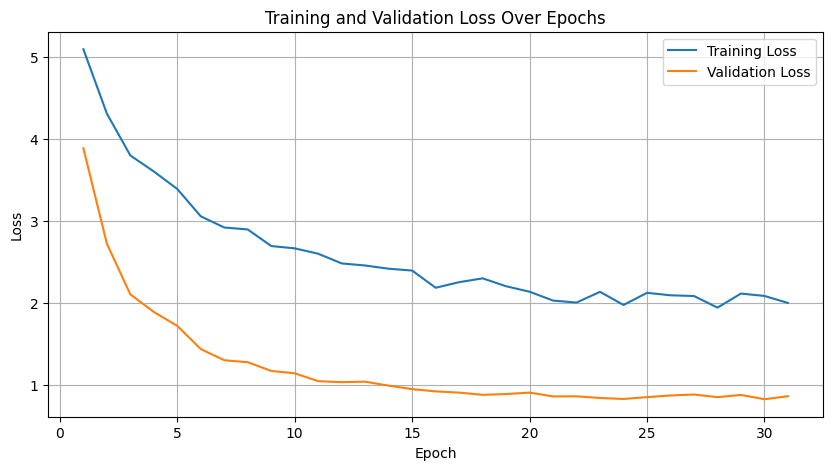

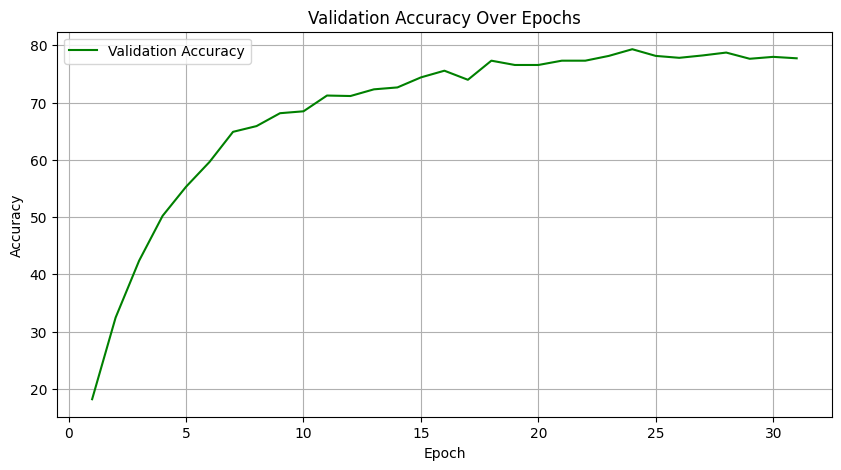

In [ ]:
# # Plot training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(history_mod['epoch'], history_mod['train_loss'], label='Training Loss')
plt.plot(history_mod['epoch'], history_mod['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid()
plt.show()

# Plot validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_mod['epoch'], history_mod['val_acc'],label = 'Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Initialize the model and load the best weights
    model = ResNetPSA().to(device)
    model.load_state_dict(torch.load('resnetpsaexp4.pth'))
    model.eval()

    # Load the test dataset
    test_dataset = datasets.ImageFolder('data/test', transform=base_transform)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            all_preds.append(outputs.argmax(1).cpu())
            all_targets.append(targets.cpu())  # Move targets back to CPU for evaluation

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    # Calculate overall accuracy
    acc = (all_preds == all_targets).mean()
    print(f'Final Test Accuracy: {acc*100:.4f}%')

    # Classification report
    class_names = test_dataset.classes
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))

In [ ]:
evaluate_model()

/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/kkharel2/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Final Test Accuracy: 78.6331%

Classification Report:
                                    precision    recall  f1-score   support

        001.Black_footed_Albatross       0.67      0.73      0.70        30
              002.Laysan_Albatross       0.85      0.73      0.79        30
               003.Sooty_Albatross       0.71      0.96      0.82        28
             004.Groove_billed_Ani       0.81      0.83      0.82        30
                005.Crested_Auklet       0.91      0.71      0.80        14
                  006.Least_Auklet       0.91      0.91      0.91        11
               007.Parakeet_Auklet       0.92      1.00      0.96        23
             008.Rhinoceros_Auklet       0.76      0.89      0.82        18
              009.Brewer_Blackbird       0.55      0.55      0.55        29
          010.Red_winged_Blackbird       0.97      0.93      0.95        30
               011.Rusty_Blackbird       0.64      0.60      0.62        30
       012.Yellow_headed_Blackbir

-------------------------------------------------------------

# Additional Section to upload the birds species and see the class prediction

--------------------------------------------------------------------------------

In [32]:
# Load the trained model
def load_model(model_path, num_classes=200):
    model = ResNetPSA(num_classes=num_classes)
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))  # Load on CPU
    model.eval()
    return model

# Preprocess the uploaded image
def preprocess_image(image):
  transform = transforms.Compose([
      transforms.Resize(256),          # Resize to 256x256 first
      transforms.CenterCrop(224),      # Then take a 224x224 center crop
      transforms.ToTensor(),           # Convert to tensor
      transforms.Normalize(            # Normalize with ImageNet stats
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225]
      )
  ])
  return transform(image)


# Classifying the uploaded image
def classify_image(model, image_tensor):
    with torch.no_grad():
        output = model(image_tensor)
        _, predicted_class = torch.max(output, 1)
    return predicted_class.item() +1

In [34]:
# Function to handle the uploaded image
def handle_upload(change):
    if not upload_widget.value:
        print("No file uploaded.")
        return

    # Get the uploaded file
    uploaded_file = next(iter(upload_widget.value.values()))
    image_data = uploaded_file['content']
    image = Image.open(io.BytesIO(image_data)).convert('RGB')

    # Preprocessing
    image_tensor = preprocess_image(image)

    predicted_class = classify_image(model, image_tensor)
    display(image.resize((224, 224)))
    print(f"Predicted Bird Class: {predicted_class+1}")

FileUpload(value={}, accept='.jpg,.jpeg,.png', description='Upload')

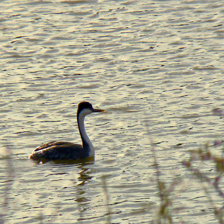

Predicted Bird Class: 53


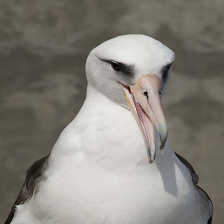

Predicted Bird Class: 2


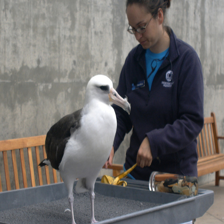

Predicted Bird Class: 2


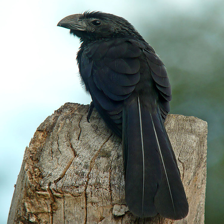

Predicted Bird Class: 107


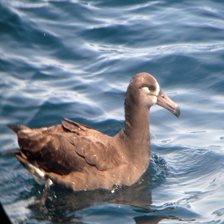

Predicted Bird Class: 1


In [35]:
# Classify the uploaded image
def classify_image(model, image_tensor):
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0))  # Add batch dimension (B, C, H, W)
        _, predicted_class = torch.max(output, 1)
    return predicted_class.item()


upload_widget = widgets.FileUpload(accept='.jpg,.jpeg,.png', multiple=False)
display(upload_widget)
upload_widget.observe(handle_upload, names='value')  # Attach the handler to the upload widget

# Loading the model
model_path = 'resnetpsaexp4.pth'
model = load_model(model_path)